------------------------------------

## Import the packages and load the data

In [1]:
%run ../../../Script/analysisLibraries

In [2]:
%run ../../../Script/pythonScripts.py

In [3]:
%matplotlib inline

In [4]:
%load_ext rpy2.ipython

In [5]:
import topo as tp

In [6]:
rcParams['figure.figsize']=(6,6) #rescale figures

Define sample name

In [7]:
sample = 'CELLS'

Load data Matrix

In [ ]:
adata = sc.read_mtx(f'../../../Data/Carl/{sample}/matrix.mtx')
adata = adata.T.copy()

Cells barcodes and gene names

In [ ]:
cells = pd.read_csv(f'../../../Data/Carl/{sample}/barcodes.tsv', header=None)

In [ ]:
adata.obs_names = cells.iloc[:,0]

In [ ]:
genes = pd.read_csv(f'../../../Data/Carl/{sample}/features.tsv', sep='\t', header=None)

In [ ]:
adata.var_names = genes.iloc[:,0]

Read spliced and unspliced data

In [ ]:
sdata = sc.read_mtx(f'../../../Data/Carl/{sample}_VELO/spliced_matrix.mtx')
sdata = sdata.T.copy()

Cells barcodes and gene names

In [ ]:
cells = pd.read_csv(f'../../../Data/Carl/{sample}_VELO/spliced_barcodes.tsv', header=None)

In [ ]:
sdata.obs_names = cells.iloc[:,0]

In [ ]:
genes = pd.read_csv(f'../../../Data/Carl/{sample}_VELO/spliced_features.tsv', sep='\t', header=None)

In [ ]:
sdata.var_names = genes.iloc[:,0]

In [ ]:
udata = sc.read_mtx(f'../../../Data/Carl/{sample}_VELO/unspliced_matrix.mtx')
udata = udata.T.copy()

Cells barcodes and gene names

In [ ]:
cells = pd.read_csv(f'../../../Data/Carl/{sample}_VELO/unspliced_barcodes.tsv', header=None)

In [ ]:
udata.obs_names = cells.iloc[:,0]

In [ ]:
genes = pd.read_csv(f'../../../Data/Carl/{sample}_VELO/unspliced_features.tsv', sep='\t', header=None)

In [ ]:
udata.var_names = genes.iloc[:,0]

Integrating spliced and unspliced matrices into the main data

In [ ]:
adata = adata[ np.intersect1d(adata.obs_names, sdata.obs_names), ].copy()
adata.layers['spliced'] = sdata[adata.obs_names,:].X.copy()
adata = adata[ np.intersect1d(adata.obs_names, udata.obs_names), ].copy()
adata.layers['unspliced'] = udata[adata.obs_names,:].X.copy()

In [ ]:
!mkdir -p ./write
adata.write(f'./write/{sample}.flt.1.h5ad')

Calculate spliced and unspliced proportions

In [ ]:
adata = sc.read(f'./write/{sample}.flt.1.h5ad')

Only considering the two last: ['.1', '.h5ad'].
Only considering the two last: ['.1', '.h5ad'].


In [ ]:
tot_spl = np.sum( adata.layers['spliced'], 1 )
tot_uns = np.sum( adata.layers['unspliced'], 1 )

adata.obs['spl_prop'] =  tot_spl/(tot_uns+tot_spl)
adata.obs['uns_prop'] =  tot_uns/(tot_uns+tot_spl)

We calculate the percentage of ribosomal protein genes and mitochondrial genes into each cell. We look at genes that contain `RPS` or `RPL` and `MT-` into their ID, and calculate their transcript proportion into each cell. We save the result as an observation into `.obs['perc_rp']` and `.obs['perc_mito']`

In [ ]:
import re
RP = [ re.match("^RP[SL]",i)!=None for i in adata.var_names]
perc_rp = np.sum( adata[:,RP].X, 1 ) / np.sum( adata.X, 1 )
adata.obs['perc_rp'] = perc_rp.copy()

In [ ]:
MT = ['MT' in i for i in adata.var_names]
perc_mito = np.sum( adata[:,MT].X, 1 ) / np.sum( adata.X, 1 )
adata.obs['perc_mito'] = perc_mito.copy()

Calculate various quality measures

In [ ]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

# Denoising

using soupX on all matrices (spliced, unspliced, full)

Remove useless genes and drops with few transcripts

In [ ]:
adata.var_names = [i.replace("_","-") for i in adata.var_names]

In [ ]:
sc.pp.filter_genes(adata, min_cells=1)

Full dataset to check ambient RNA in soupX

In [ ]:
fulldata = sc.read_mtx(f'../../../Data/Carl/cellranger/{sample}_RAW/matrix.mtx.gz')
fulldata = fulldata.T.copy()

In [ ]:
sc.pp.calculate_qc_metrics(fulldata, inplace=True)

Cells barcodes and gene names

In [ ]:
cells = pd.read_csv(f'../../../Data/Carl/cellranger/{sample}_RAW/barcodes.tsv.gz', header=None)

In [ ]:
fulldata.obs_names = cells.iloc[:,0]

In [ ]:
genes = pd.read_csv(f'../../../Data/Carl/cellranger/{sample}_RAW/features.tsv.gz', sep='\t', header=None)

In [ ]:
fulldata.var_names = genes.iloc[:,0]

In [ ]:
fulldata.var_names = [i.replace("_","-") for i in fulldata.var_names]

In [ ]:
np.sum(fulldata.obs['total_counts']>5)

89168

In [ ]:
fulldata2 = fulldata[fulldata.obs['total_counts']>3].copy()

In [ ]:
sc.pp.filter_genes(fulldata2, min_cells=1)

Intersect

In [ ]:
intersection = np.intersect1d(fulldata2.var_names, adata.var_names)

### SoupX on all counts

In [ ]:
rawMatrix = np.array(adata[:,intersection].X.todense().T, dtype='int16')
cells = adata[:,intersection].obs_names
genes = adata[:,intersection].var_names

In [ ]:
fullMatrix = np.array(fulldata2[:,intersection].X.todense().T, dtype='int16')
fullcells = fulldata2[:,intersection].obs_names
fullgenes = fulldata2[:,intersection].var_names

In [ ]:
%%R -i rawMatrix -i fullMatrix -i cells -i genes -i fullcells -i fullgenes

library(Seurat)
library(SoupX)

In [ ]:
%%R

colnames(fullMatrix) <- fullcells
rownames(fullMatrix) <- fullgenes
seurat_full <- CreateSeuratObject(fullMatrix)

colnames(rawMatrix) <- cells
rownames(rawMatrix) <- genes
seurat_filt <- CreateSeuratObject(rawMatrix)

Some normalization

In [ ]:
%%R

seurat_filt <- SCTransform(seurat_filt, verbose = TRUE, 
                         variable.features.n = 2000)
seurat_filt    <- RunPCA(seurat_filt, verbose = T)
seurat_filt    <- RunUMAP(seurat_filt, dims = 0:25, verbose = T)
seurat_filt    <- FindNeighbors(seurat_filt, dims = 0:25, verbose = T)
seurat_filt    <- FindClusters(seurat_filt, verbose=T)

R[write to console]: Calculating cell attributes from input UMI matrix: log_umi

R[write to console]: Variance stabilizing transformation of count matrix of size 26037 by 5346

R[write to console]: Model formula is y ~ log_umi

R[write to console]: Get Negative Binomial regression parameters per gene

R[write to console]: Using 2000 genes, 5000 cells



  |======================================================================| 100%


R[write to console]: Found 47 outliers - those will be ignored in fitting/regularization step


R[write to console]: Second step: Get residuals using fitted parameters for 26037 genes



  |======================================================================| 100%


R[write to console]: Computing corrected count matrix for 26037 genes



  |======================================================================| 100%


R[write to console]: Calculating gene attributes

R[write to console]: Wall clock passed: Time difference of 1.166302 mins

R[write to console]: Determine variable features

R[write to console]: Place corrected count matrix in counts slot

R[write to console]: Centering data matrix

  |                                                                            
  |                                                                      |   0%
  |                                                                            
  |=======================                                               |  33%
  |                                                                            
  |===============================================                       |  67%
  |                                                                            
  |======================================================================| 100%
R[write to console]: 

R[write to console]: Set default assay to SCT

R[writ

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5346
Number of edges: 162323

Running Louvain algorithm...


R[write to console]: 0%   10   20   30   40   50   60   70   80   90   100%

R[write to console]: [----|----|----|----|----|----|----|----|----|----|

R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: 

Maximum modularity in 10 random starts: 0.9074
Number of communities: 22
Elapsed time: 0 seconds


Setup and run soupX

In [ ]:
%%R
soup.channel <- SoupChannel(fullMatrix, rawMatrix)
meta    <- seurat_filt@meta.data
umap    <- seurat_filt@reductions$umap@cell.embeddings
soup.channel  <- setClusters(soup.channel, setNames(meta$seurat_clusters, rownames(meta)))
soup.channel  <- setDR(soup.channel, umap)
head(meta)

                    orig.ident nCount_RNA nFeature_RNA nCount_SCT nFeature_SCT
AAACCCACAACGCCCA SeuratProject       1173          940       6387         2470
AAACCCACACATTCGA SeuratProject      13579         5661       9534         5523
AAACCCAGTCTAGGCC SeuratProject       7478         4123       7628         4123
AAACCCATCGTTCCCA SeuratProject     109880        11424       8692         4265
AAACGAAAGATGATTG SeuratProject      19942         6662       9296         5071
AAACGAAAGGGTAATT SeuratProject      19300         3911       8885         2734
                 SCT_snn_res.0.8 seurat_clusters
AAACCCACAACGCCCA               0               0
AAACCCACACATTCGA               6               6
AAACCCAGTCTAGGCC               7               7
AAACCCATCGTTCCCA               4               4
AAACGAAAGATGATTG               6               6
AAACGAAAGGGTAATT              13              13


R[write to console]: 11275 genes passed tf-idf cut-off and 200 soup quantile filter.  Taking the top 100.

R[write to console]: Using 1379 independent estimates of rho.

R[write to console]: Estimated global rho of 0.12



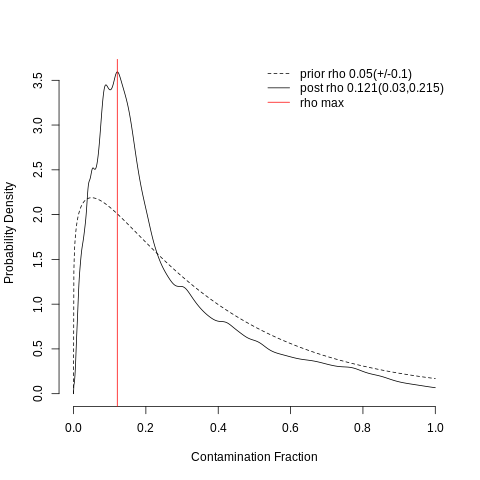

In [ ]:
%%R

soup.channel  <- autoEstCont(soup.channel)

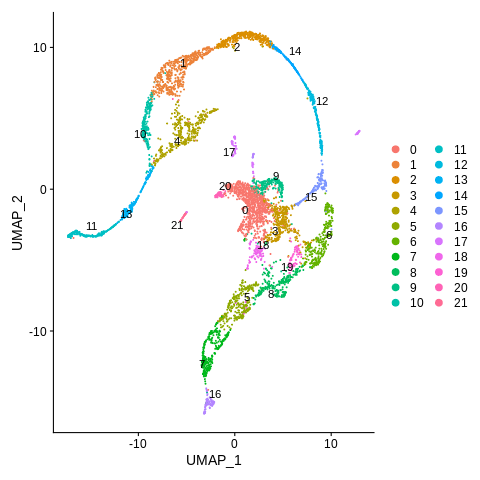

In [ ]:
%%R
# visualise UMAP embedding and clustering for 25 PCs
#     note - clusters not necessarily biologically relevant!
DimPlot(seurat_filt, label = T, repel = T)# + ggtitle("Unsupervised clustering")

Which genes had highest contamination. Preview and save the table.

In [ ]:
%%R

head(soup.channel$soupProfile[order(soup.channel$soupProfile$est, decreasing = T), ], n = 20)

                     est counts
PRM1         0.021259212   6609
PRM2         0.016498487   5129
TNP1         0.011232738   3492
MTRNR2L14    0.004760725   1480
GPX4         0.003203839    996
LOC104001214 0.003152372    980
HMGB4        0.003036571    944
GSTM3        0.002846785    885
H2AFJ        0.002573365    800
LOC740298    0.002454347    763
YBX1         0.002438263    758
COX7A2       0.002280645    709
H3F3B        0.002206661    686
UBB          0.002045825    636
ANKRD7       0.002042608    635
SPINK2       0.001917157    596
HSP90AA1     0.001897857    590
NDUFAF3      0.001811006    563
CALM3        0.001663037    517
BOD1L2       0.001608353    500


In [ ]:
%%R

write.csv(file='tables/contaminatedUMI.csv', soup.channel$soupProfile[order(soup.channel$soupProfile$est, decreasing = T), ])

In [ ]:
%%R -o adj_matrix

adj_matrix  <- adjustCounts(soup.channel, roundToInt = T)

R[write to console]: Expanding counts from 22 clusters to 5346 cells.



In [ ]:
%%R -o genesAdj

genesAdj <- rownames(soup.channel$toc)

In [ ]:
adj_matrix.T.shape == adata.shape

False

In [ ]:
adata = adata[:,genesAdj].copy()

In [ ]:
adata.layers['soupx_counts'] = np.array(adj_matrix.todense().T)

In [ ]:
adata.layers['raw_counts'] = adata.X.copy()

In [ ]:
adata.write(f'./write/{sample}.flt.2.h5ad')

## Visualize quality measure distributions

### One-dimensional distributions

In [8]:
adata = sc.read(f'../cells_analysis_LQ/write/{sample}.flt.2.h5ad')

Only considering the two last: ['.2', '.h5ad'].
Only considering the two last: ['.2', '.h5ad'].


In [9]:
adata.X = adata.layers['soupx_counts']

In [10]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

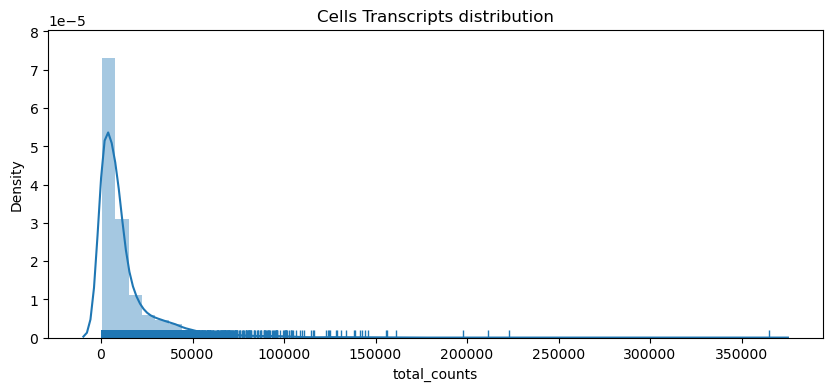

In [11]:
fig, ax = plt.subplots(1,1, figsize=(10,4))
fig1 = sns.distplot(adata.obs['total_counts'], bins=50, rug=True)
title1 = ax.set_title('Cells Transcripts distribution')

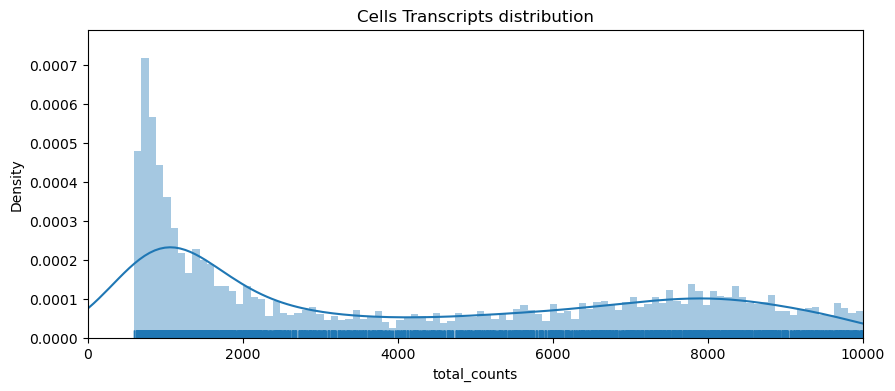

In [27]:
fig, ax = plt.subplots(1,1, figsize=(10,4))
fig1 = sns.distplot(adata[adata.obs['total_counts']<10000].obs['total_counts'], bins=100, rug=True)
plt.xlim(0, 10000)
title1 = ax.set_title('Cells Transcripts distribution')

We do a similar analysis with the thresholds for the number of genes detected in each droplet. 

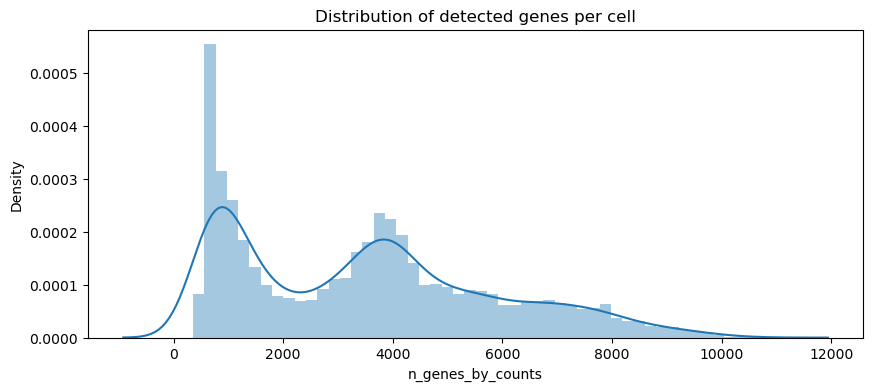

In [13]:
fig, ax = plt.subplots(1,1, figsize=(10,4))
fig1 = sns.distplot(adata.obs['n_genes_by_counts'], bins=50)
title1 = ax.set_title('Distribution of detected genes per cell')

**Mitochondrial content**: In this dataset there arebasically no cells with a high percentage of mitochondrial genes

In [14]:
#subsetting to see how many cells have percentage of mitochondrial genes above usual threshold of 10%
adata[ adata.obs['perc_mito']>0.1, : ].shape[0]

2

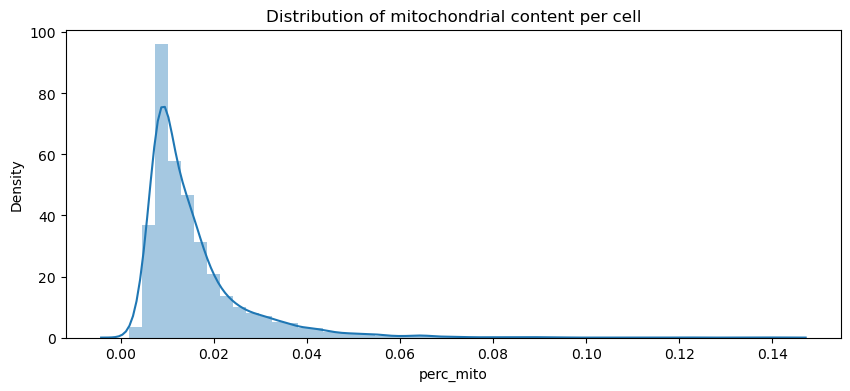

In [15]:
fig, ax = plt.subplots(1,1, figsize=(10,4))
fig1 = sns.distplot(adata.obs['perc_mito'], bins=50)
title1 = ax.set_title('Distribution of mitochondrial content per cell')

**Ribosomal content**: The percentage of ribosomal protein genes is also very low, so we do not really need to do any filtering on that as well

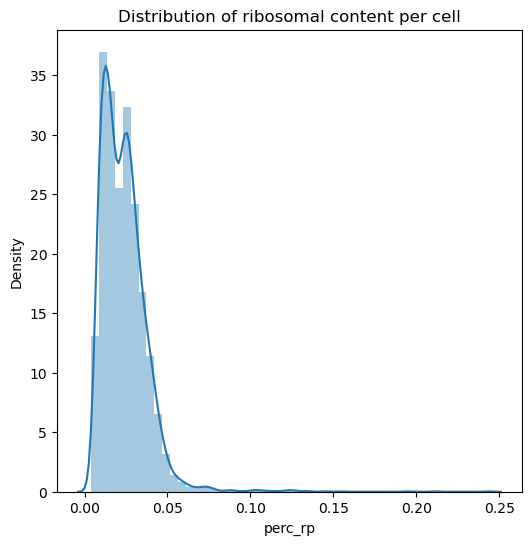

In [16]:
ax = sns.distplot(adata.obs['perc_rp'], bins=50)
x = ax.set_title('Distribution of ribosomal content per cell')

We can see how many droplets contain more than 5% of ribosomal protein transcripts

In [17]:
f'Max ribosomal transcript threshold overstepped by {sum(adata.obs["perc_rp"]>0.05)} cells'

'Max ribosomal transcript threshold overstepped by 150 cells'

**Spliced content**: We can observe two peaks. We want to remove the one on the extreme right of the plot, for example with a threshold of 0.8

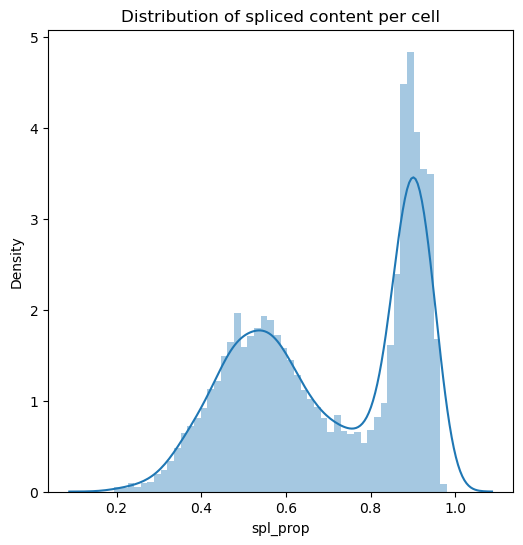

In [18]:
ax = sns.distplot(adata.obs['spl_prop'], bins=50)
x = ax.set_title('Distribution of spliced content per cell')

### Bidimensional patterns


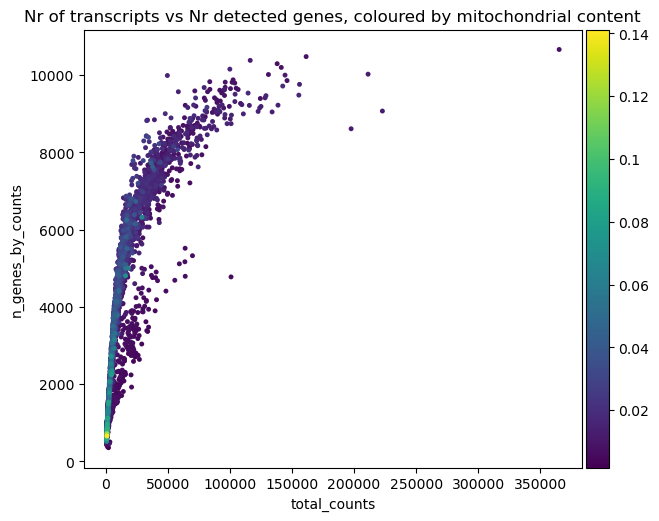

In [19]:
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='perc_mito', 
              title ='Nr of transcripts vs Nr detected genes, coloured by mitochondrial content',
             size=50)

### Abnormal amount of transcripts from a gene

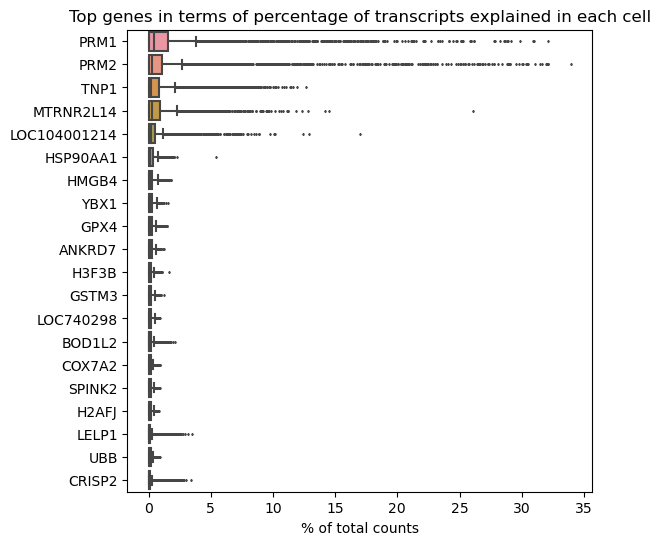

In [20]:
fig, ax = plt.subplots(1,1)
ax.set_title('Top genes in terms of percentage of transcripts explained in each cell')
fig = sc.pl.highest_expr_genes(adata, n_top=20, ax=ax)

You can save the percentages of transcripts expressing some genes identified above. We do not need this here, but we run the code just for completeness.

In [21]:
GENES = ['PRM1', 'PRM2', 'TNP1','MTRNR2L14','LOC104001214','HSP90AA1']

for G in GENES:
    perc = np.sum( adata[:,G].X, 1 ) / np.sum( adata.X, 1 )
    adata.obs[f'perc_{G}'] = perc.copy()

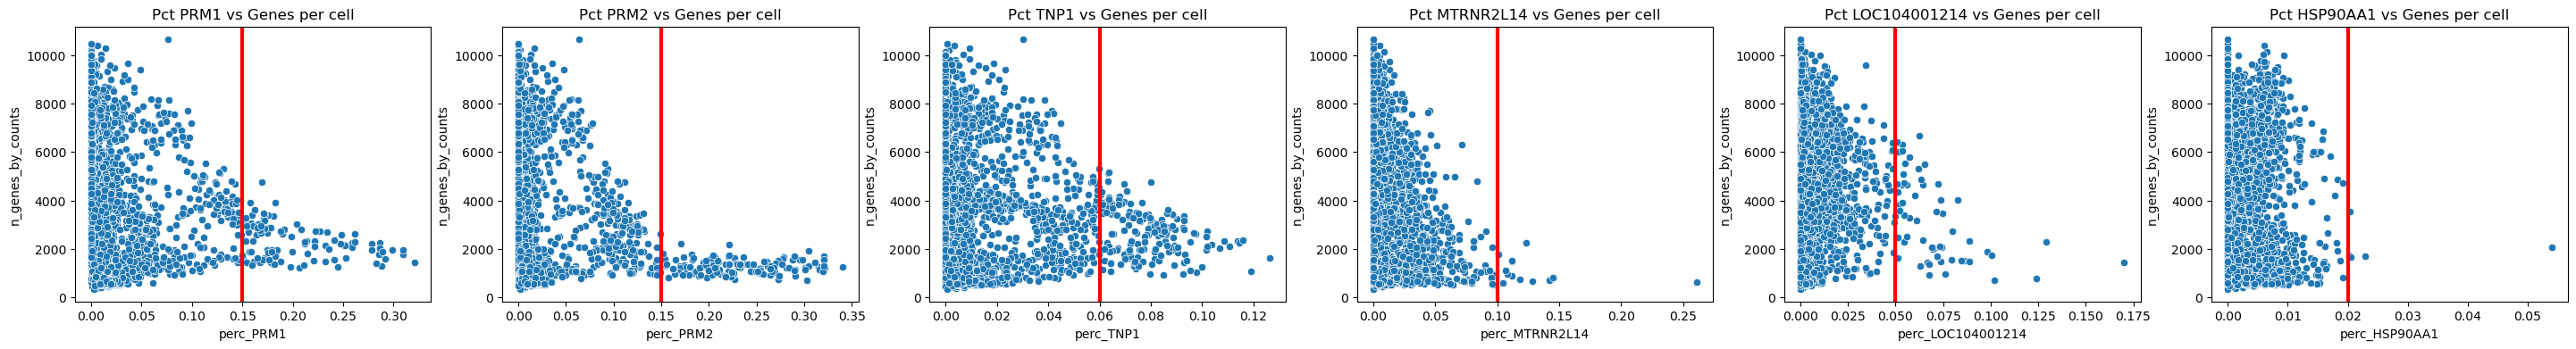

In [22]:
#some thresholds based on the plots below
thresholds = [.15, .15, .06, .1, .05, .02]

#do the plots and check the thresholds you prefere, and change them in the code line above to plot again
L = len(thresholds)
fig, ax = plt.subplots(1, L, figsize=(L*6,4))



#ax.set_title('Top genes in terms of percentage of transcripts explained in each cell')
for G,T,A in zip(GENES, thresholds, ax):
    A.set_title(f'Pct {G} vs Genes per cell')
    fig1 = sns.scatterplot( x=adata.obs[f'perc_{G}'], y=adata.obs['n_genes_by_counts'], ax=A )
    fig1.axvline(x=T, lw=3, c='r')

How many cells would we remove with these thresholds?

In [23]:
#find droplets above one of the thresholds
total = np.zeros( adata.shape[0], dtype='bool8' )
for G,T in zip(GENES, thresholds):
    total = (total) | (adata.obs[f'perc_{G}']>T)

#save the identifier into the data
adata.obs['genes_threshold_filter'] = pd.Categorical(total).copy()

In [24]:
#count all the cells above thresholds
f'You will filter out in total {sum(total)} cells'

'You will filter out in total 404 cells'

## Choosing thresholds and filtering

We now establish all the filtering values discussed until now by looking at distributions.

In [38]:
MIN_COUNTS = 1500  #minimum number of transcripts per cell
MAX_COUNTS = 80000 #maximum number of transcripts per cell
MIN_GENES = 1500   #minimum number of genes per cell
MAX_GENES = 11000   #maximum number of genes per cell
MAX_MITO = .1      #mitochondrial percentage threshold
MAX_RP = .1     #ribosomal percentage threshold
MAX_SPL = .8

We can also plot all the points we are going to filter out. We save `all_filters` in the data. This contains all filters defined until now to detect points to remove.

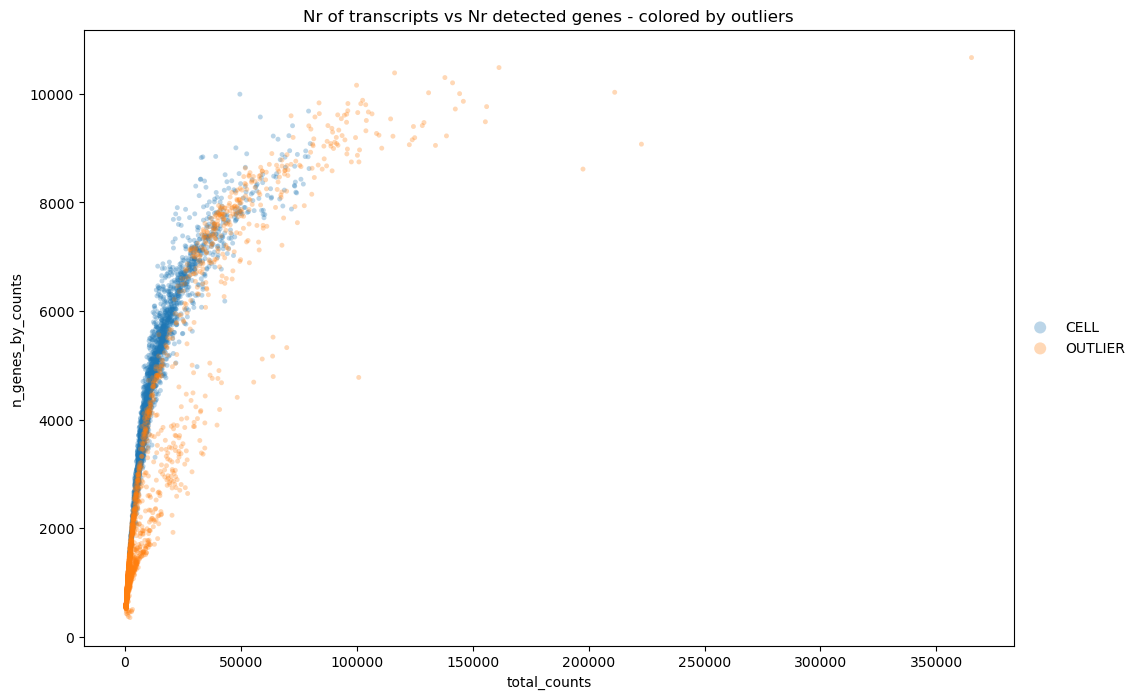

In [39]:
#define an indicator to remove cells
all_filters = (adata.obs['total_counts']>MAX_COUNTS) | (adata.obs['total_counts']<MIN_COUNTS) | \
            (adata.obs['n_genes_by_counts']<MIN_GENES) | (adata.obs['n_genes_by_counts']>MAX_GENES) | \
            (adata.obs['perc_mito']>MAX_MITO) | (adata.obs['perc_mito']>MAX_RP) |\
            (adata.obs['perc_PRM1']>0.15) | (adata.obs['perc_PRM2']>0.15) | (adata.obs['perc_TNP1']>0.06) | (adata.obs['perc_MTRNR2L14']>0.075) | (adata.obs['perc_LOC104001214']>0.075) |\
            (adata.obs['spl_prop']>MAX_SPL)  


adata.obs['all_filters'] = pd.Categorical(all_filters).rename_categories(['CELL','OUTLIER'])
            
fig, ax = plt.subplots(1,1, figsize=(12,8))

#plot cells filtered by max transcripts
fig1 = sc.pl.scatter(adata, alpha=.3,
             x='total_counts', y='n_genes_by_counts', color='all_filters', size=50,
              title =f'Nr of transcripts vs Nr detected genes - colored by outliers', ax=ax, )

In [40]:
adata = adata[ adata.obs['all_filters'] == "CELL" ].copy()

sc.preprocessing.filter_genes(adata, min_cells=10)

### Filtering based on the spl prop in the clustering

In [41]:
adata2 = adata.copy()

In [42]:
sc.pp.normalize_total(adata2)
sc.pp.log1p(adata2)
sc.pp.highly_variable_genes(adata2)
sc.pp.scale(adata2, max_value=10)

In [43]:
sc.pp.pca(adata2, random_state=123)
sc.pp.neighbors(adata2, random_state=123)
sc.tl.umap(adata2, random_state=123)
sc.tl.leiden(adata2, resolution=.7, random_state=123)

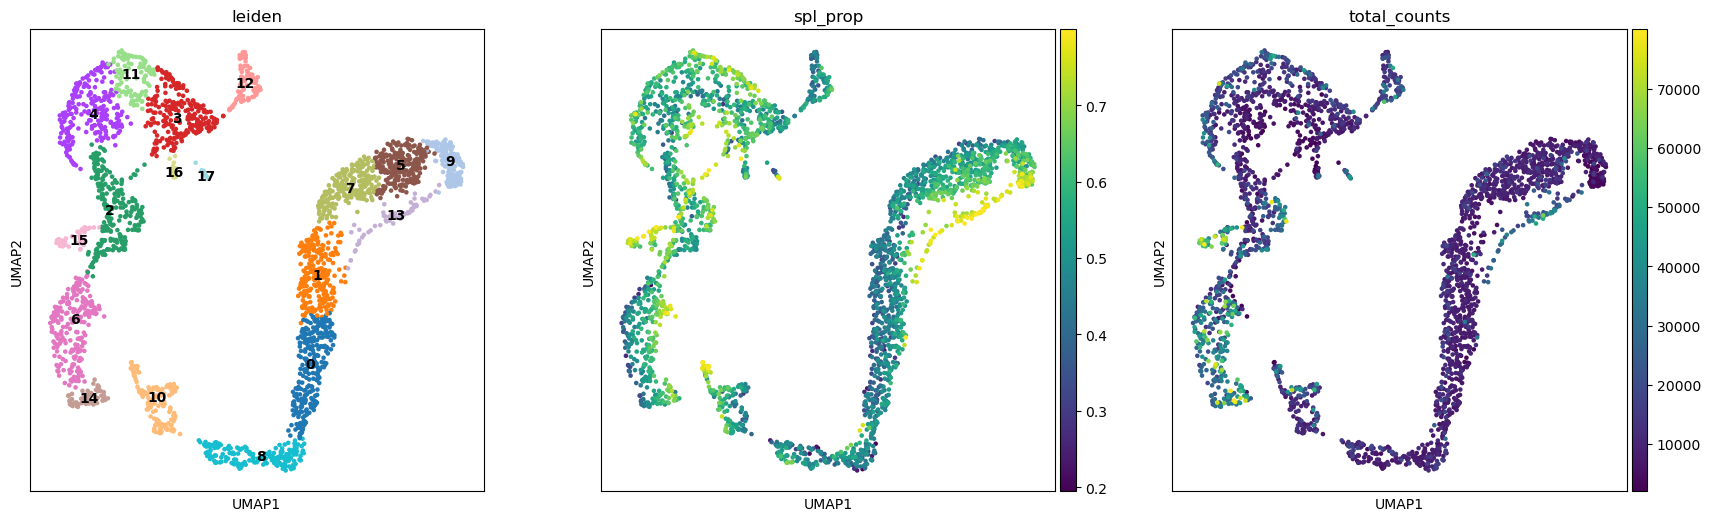

In [44]:
sc.pl.umap(adata2, color=['leiden','spl_prop','total_counts'], legend_loc='on data')

In [46]:
adata.write(f'./write/{sample}.flt.3.h5ad')

Set filtering and ckeck on UMAP

## Doublet filtering

In [48]:
adata = sc.read(f'./write/{sample}.flt.3.h5ad')

Only considering the two last: ['.3', '.h5ad'].
Only considering the two last: ['.3', '.h5ad'].


In [49]:
sc.external.pp.scrublet(adata, 
                        expected_doublet_rate=0.04,
                        random_state=12345)

Automatically set threshold at doublet score = 0.22
Detected doublet rate = 0.8%
Estimated detectable doublet fraction = 49.1%
Overall doublet rate:
	Expected   = 4.0%
	Estimated  = 1.6%


In the code above, `random_state` is a number choosing how the simulations are done. Using a specific random state means that you will always simulate the same doublets whenever you run this code. This allows you to reproduce exactly the same results every time and is a great habit to have for reproducibility in your own research.

According to scrublet, the percentage of doublets is high. But we can see that most cells have a low score (the score is a value between 0 and 1). A score of 1 means a data point is a perfect doublet as from simulations. Datasets with many doublets show a more bimodal distribution (look for example at [this example](https://github.com/swolock/scrublet/blob/master/examples/scrublet_basics.ipynb) from the `scrublet` tutorial), while here we just have a slight peak beyond 0.1, where we set our threshold. 

In [50]:
%matplotlib inline

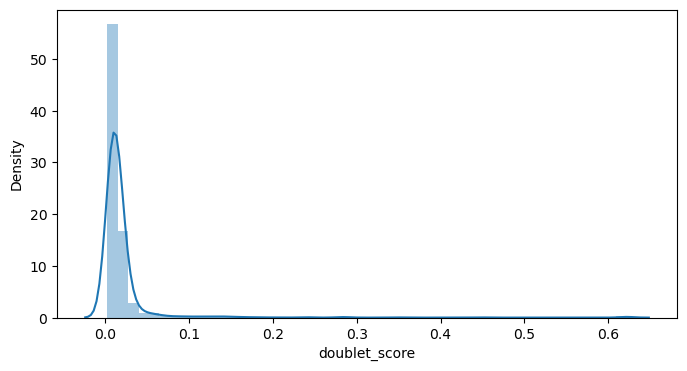

In [51]:
fig, ax = plt.subplots(1,1, figsize=(8,4))

fig1 = sns.distplot(adata.obs['doublet_score'])

We can choose 0.1 as filtering threshold for the few detected doublets or alternatively use the automatic selection of doublets by the algorithm. The automatic choice is not always very good, and works when there are two clear peaks in the histogram. Therefore it is often better to look at the histogram and choose manually a threshold.

In [52]:
adata = adata[ adata.obs['doublet_score']<0.1 ].copy()

In [53]:
print(f'Cells after doublet filter: {adata.shape[0]}, Genes after filters: {adata.shape[1]}')

Cells after doublet filter: 2707, Genes after filters: 24421


In [54]:
adata.write(f'./write/adata.flt.4.h5ad')

# Normalization

In [55]:
adata = sc.read(f'./write/adata.flt.4.h5ad')

Only considering the two last: ['.4', '.h5ad'].
Only considering the two last: ['.4', '.h5ad'].


In [56]:
adata.X = adata.layers['soupx_counts'].copy()

In [57]:
# Normalization and log-transformation for variance stabilization
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
# Selection of highly-variable genes
sc.pp.highly_variable_genes(adata)
# Z-score transformation
sc.pp.scale(adata, max_value=10)

In [58]:
adata.layers['soupx_Z_counts'] = adata.X.copy()

In [59]:
adata.write(f'./write/adata.norm.1.h5ad')

# PCA Projection + umap

In [60]:
adata = sc.read(f'./write/adata.norm.1.h5ad')

Only considering the two last: ['.1', '.h5ad'].
Only considering the two last: ['.1', '.h5ad'].


In [61]:
sc.pp.pca(adata, random_state=123)

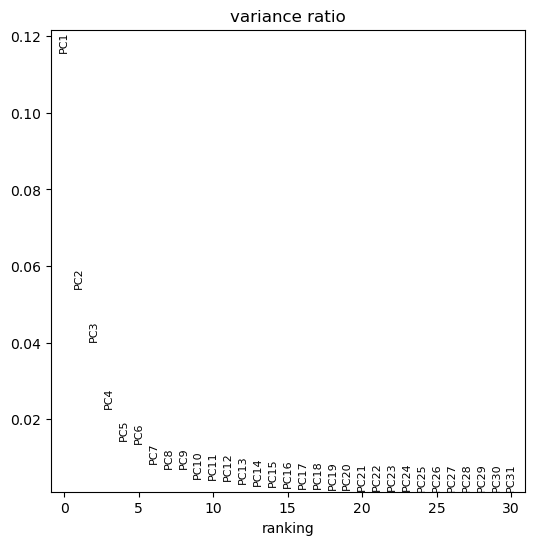

In [62]:
sc.pl.pca_variance_ratio(adata)

In [63]:
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=15, random_state=123)

In [64]:
sc.tl.umap(adata, random_state=123)

In [65]:
sc.tl.leiden(adata, resolution=.7, random_state=123)

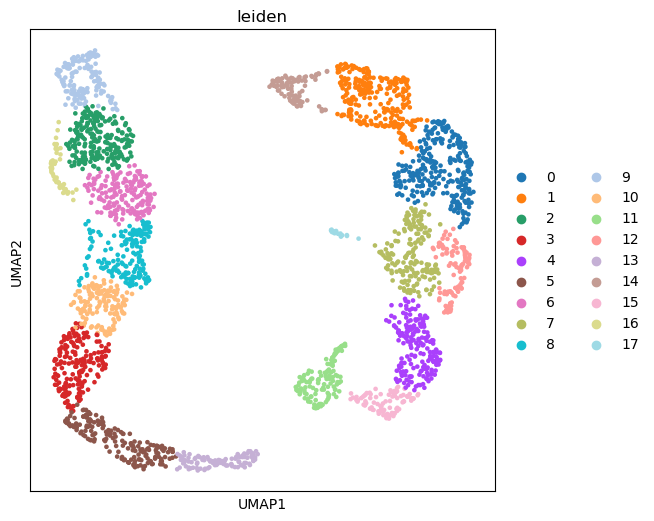

In [67]:
sc.pl.umap(adata, color=['leiden'], ncols=1)

In [68]:
adata.write(f'./write/adata.norm.topo.1.h5ad')

# Topometry

In [69]:
adata = sc.read(f'./write/adata.norm.topo.1.h5ad')

Only considering the two last: ['.1', '.h5ad'].
Only considering the two last: ['.1', '.h5ad'].


In [70]:
adataHVG = adata[:, adata.var.highly_variable].copy()

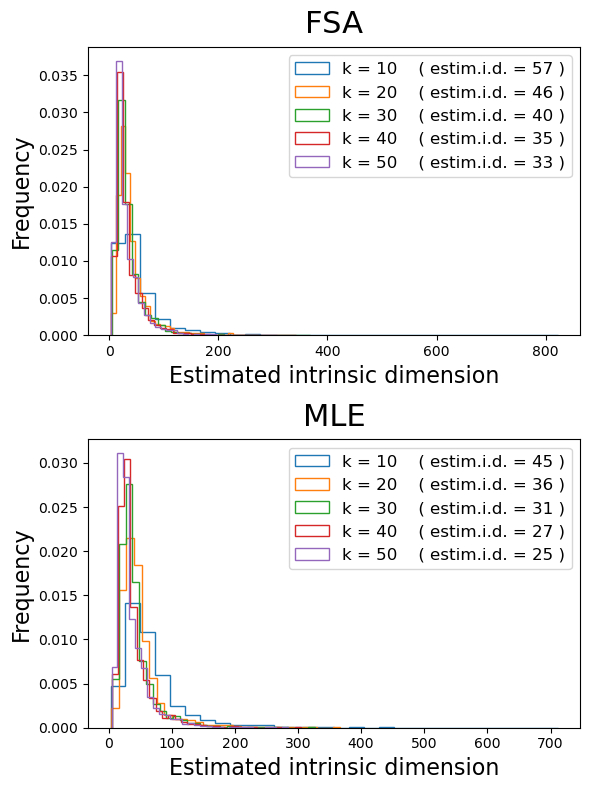

In [71]:
plt.rcParams["figure.figsize"] = (4, 4)
tp.tpgraph.IntrinsicDim(
    methods=["fsa", "mle"],
    k=range(10, 60, 10),
    backend="hnswlib",
    metric="euclidean",
    n_jobs=-1,
    plot=True,
    random_state=123,
).fit(adataHVG.X)

In [72]:
# Run TopOMetry

# Create a TopOGraph object with the desired parameters
tg = tp.TopOGraph(n_eigs=50, n_jobs=-1, verbosity=1, random_state=42)

# Fit some models to the data
adata = tp.sc.topological_workflow(
    adata,
    tg,
    kernels=["bw_adaptive"],
    eigenmap_methods=["LE","DM"],
    projections=["MAP", "PaCMAP"],
    resolution=0.5,
)

Computing neighborhood graph...
 Base kNN graph computed in 9.358347 (sec)
 Fitted the bw_adaptive kernel in 0.277921 (sec)
Computing eigenbasis...
 Fitted eigenbasis with Laplacian Eigenmaps from the bw_adaptive in 0.061719 (sec)
    Building topological graph from eigenbasis...
        Computing neighborhood graph...
 Computed in 0.061557 (sec)
 Fitted the bw_adaptive graph kernel in 0.274003 (sec)
 Computed MAP in 4.406249 (sec)
 Computed PaCMAP in 2.897195 (sec)
Computing eigenbasis...
 Fitted eigenbasis with Diffusion Maps from the bw_adaptive kernel in 0.046425 (sec)
    Building topological graph from eigenbasis...
        Computing neighborhood graph...
 Computed in 0.048172 (sec)
 Fitted the bw_adaptive graph kernel in 0.281896 (sec)
 Computed MAP in 4.032652 (sec)
 Computed PaCMAP in 2.337374 (sec)


In [73]:
adata.obsm["X_topoMAP_LE"] = adata.obsm["X_MAP of bw_adaptive from LE with bw_adaptive"]
adata.obsm["X_topoPaCMAP_LE"] = adata.obsm["X_PaCMAP of LE with bw_adaptive"]
adata.obs["topo_leiden_LE"] = adata.obs["bw_adaptive from LE with bw_adaptive_leiden"]

adata.obsm["X_topoMAP_DM"] = adata.obsm["X_MAP of bw_adaptive from DM with bw_adaptive"]
adata.obsm["X_topoPaCMAP_DM"] = adata.obsm["X_PaCMAP of DM with bw_adaptive"]
adata.obs["topo_leiden_DM"] = adata.obs["bw_adaptive from DM with bw_adaptive_leiden"]

adata.obsm["X_LE"] = adata.obsm["X_LE with bw_adaptive"]
adata.obsm["X_DM"] = adata.obsm["X_DM with bw_adaptive"]

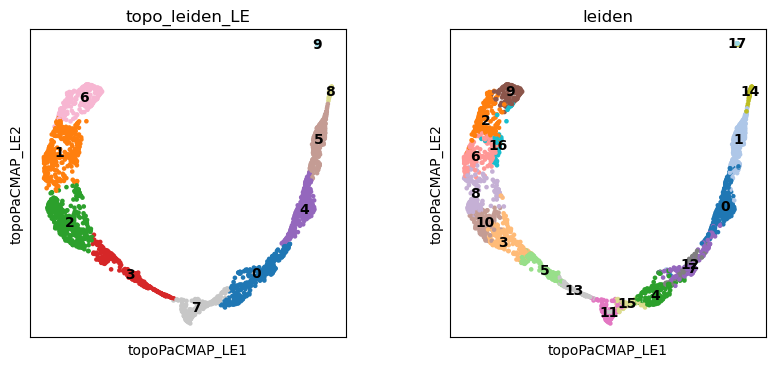

In [75]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_LE",
    color=["topo_leiden_LE","leiden"],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

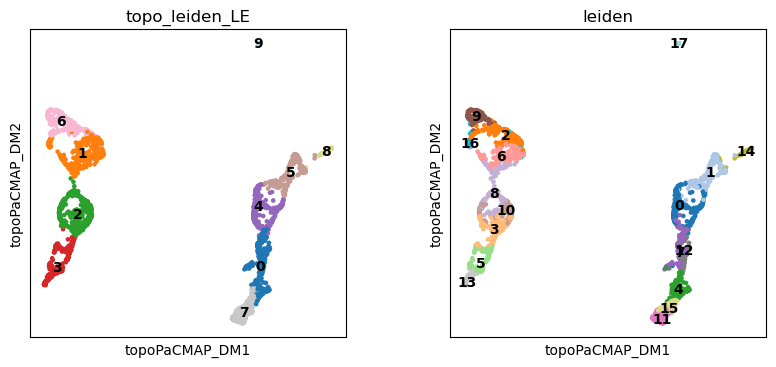

In [77]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_DM",
    color=["topo_leiden_LE","leiden"],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

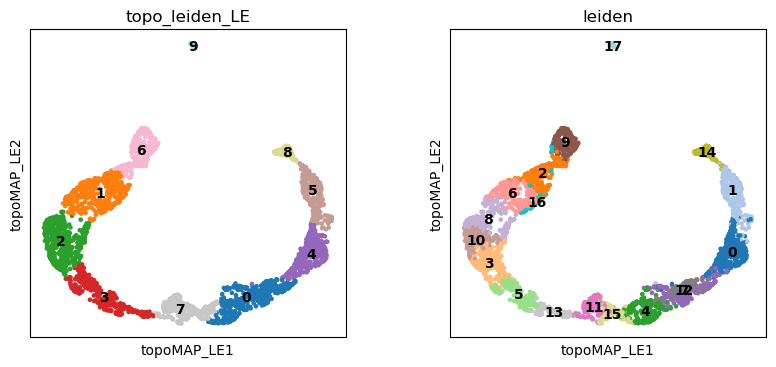

In [78]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoMAP_LE",
    color=["topo_leiden_LE","leiden"],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

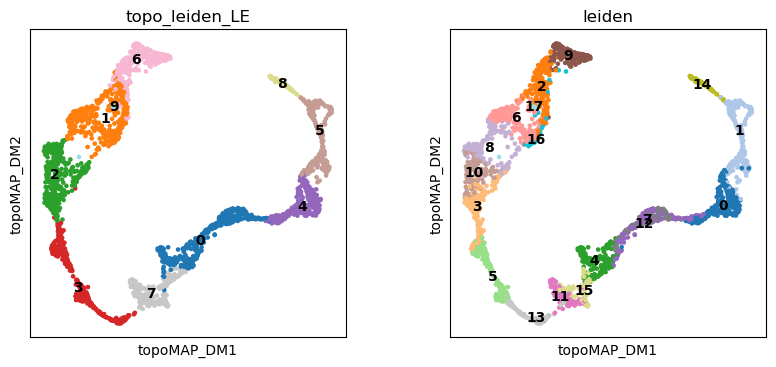

In [79]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoMAP_DM",
    color=["topo_leiden_LE","leiden"],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

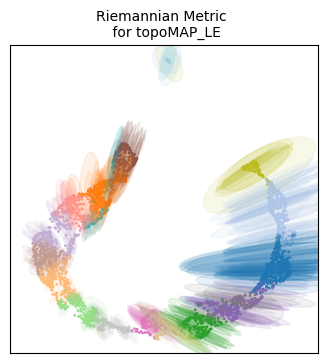

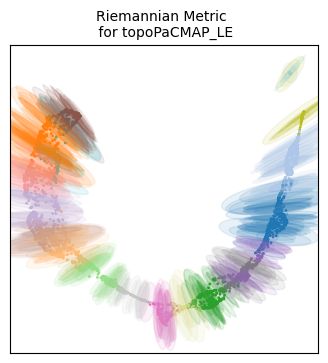

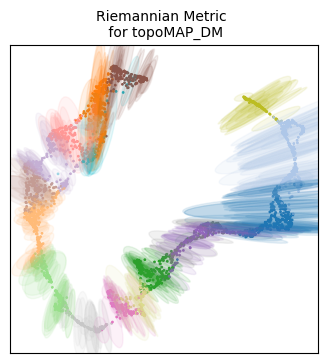

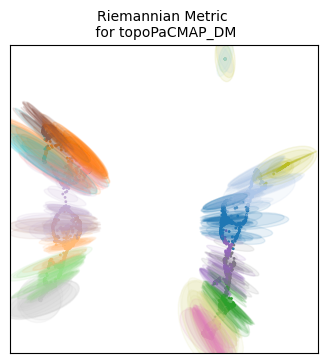

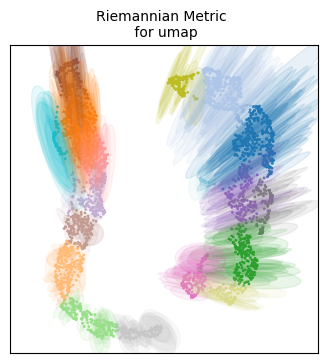

In [81]:
# Get the graph Laplacian of our base graph kernel:
L = tg.base_kernel.L

# Define how many ellipses to plot:
n_plot = 500

# Convert the labels to integers:
labels = adata.obs["leiden"].cat.codes


# Name the projections you want to plot:
projections = ["topoMAP_LE", "topoPaCMAP_LE", "topoMAP_DM", "topoPaCMAP_DM","umap"]

# Plot the Riemann metric
for name in projections:
    xy_coord = adata.obsm["X_" + name][:, :2]
    tp.pl.plot_riemann_metric(
        xy_coord,  # The coordinates of the projection
        L,  # The graph Laplacian
        std=0.5,  # A scaling factor for the ellipses size
        n_plot=n_plot,  # How many ellipses to plot
        labels=labels,
        title=f"Riemannian Metric \n for {name}",
        cmap="tab20",  # For coloring
        random_state=tg.random_state,  # For coloring with same colors as before
        figsize=(4, 4),  # Size of the figure (NEEDS TO BE SQUARE!!!),
    )

In [82]:
adata.write(f'./write/adata.norm.topo.2.h5ad')

# Clustering

Assign scores simply with highest score pereach cluster done with Leiden

In [83]:
adata = sc.read(f'./write/adata.norm.topo.2.h5ad')

Only considering the two last: ['.2', '.h5ad'].
Only considering the two last: ['.2', '.h5ad'].


In [84]:
markers = dict()  # make an empty dictionary
### SPERMATOCYTOGENESIS
markers["SpermatogoniaA"] = ["ID4", "HMGA1","NANOS2","PAX7","ZBTB16","UTF1","FGFR3"]
markers["SpermatogoniaB"] = ["MKI67", "DMRT1", "STRA8","KIT"]
#markers["SpermatocytesI"] = ["MEIOB", "PRSS50", "SYCP1", "TEX101"]
#markers["SpermatocytesII"] = ["PIWIL1", "ACRV1", "SPATA16", "CLGN","GFRA1","ZBTB16","PGK2","ACR"]
### SPERMIOGENESIS
markers["Round.Spt"] = ["SPATA9", "SPAM1","WDR7","SLC16A7"]  # Round spermatids
markers["Elong.Spt"] = ["PRM1", "PRM2","TNP1","TNP2"]  # Elongated spermatids
### SOMATIC CELLS
markers["Sertoli"] = ["CTSL", "VIM", "GATA4"]
markers["Macroph"] = ["TYROBP"]
#markers["Leydig"] = ["CFD"]
markers["Endothelial"] = ["CD34"]
markers["Myoid"] = ["ACTA2"]
markers["Smooth_Muscle"] = ["RGS5"]
### Subclusters
markers['Leptotene'] = ['SCML1']
markers['Zygotene'] = ['SYCP1','LY6K']
markers['Pachytene'] = ['CCDC112','PIWIL1','TCFL5','MLH1','MLH3']
markers['Diplotene'] = ['CCNA1','AURKA','CDK1']

In [85]:
markers_scores, adata = marker_score(markers, adata)

In [86]:
adata

AnnData object with n_obs × n_vars = 2707 × 24421
    obs: 'spl_prop', 'uns_prop', 'perc_rp', 'perc_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'perc_PRM1', 'perc_PRM2', 'perc_TNP1', 'perc_MTRNR2L14', 'perc_LOC104001214', 'perc_HSP90AA1', 'genes_threshold_filter', 'all_filters', 'doublet_score', 'predicted_doublet', 'leiden', 'bw_adaptive from LE with bw_adaptive_leiden', 'bw_adaptive from DM with bw_adaptive_leiden', 'topo_leiden_LE', 'topo_leiden_DM', 'SpermatogoniaA_score', 'SpermatogoniaB_score', 'Round.Spt_score', 'Elong.Spt_score', 'Sertoli_score', 'Macroph_score', 'Endothelial_score', 'Myoid_score', 'Smooth_Muscle_score', 'Leptotene_score', 'Zygotene_score', 'Pachytene_score', 'Diplotene_score'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_tot

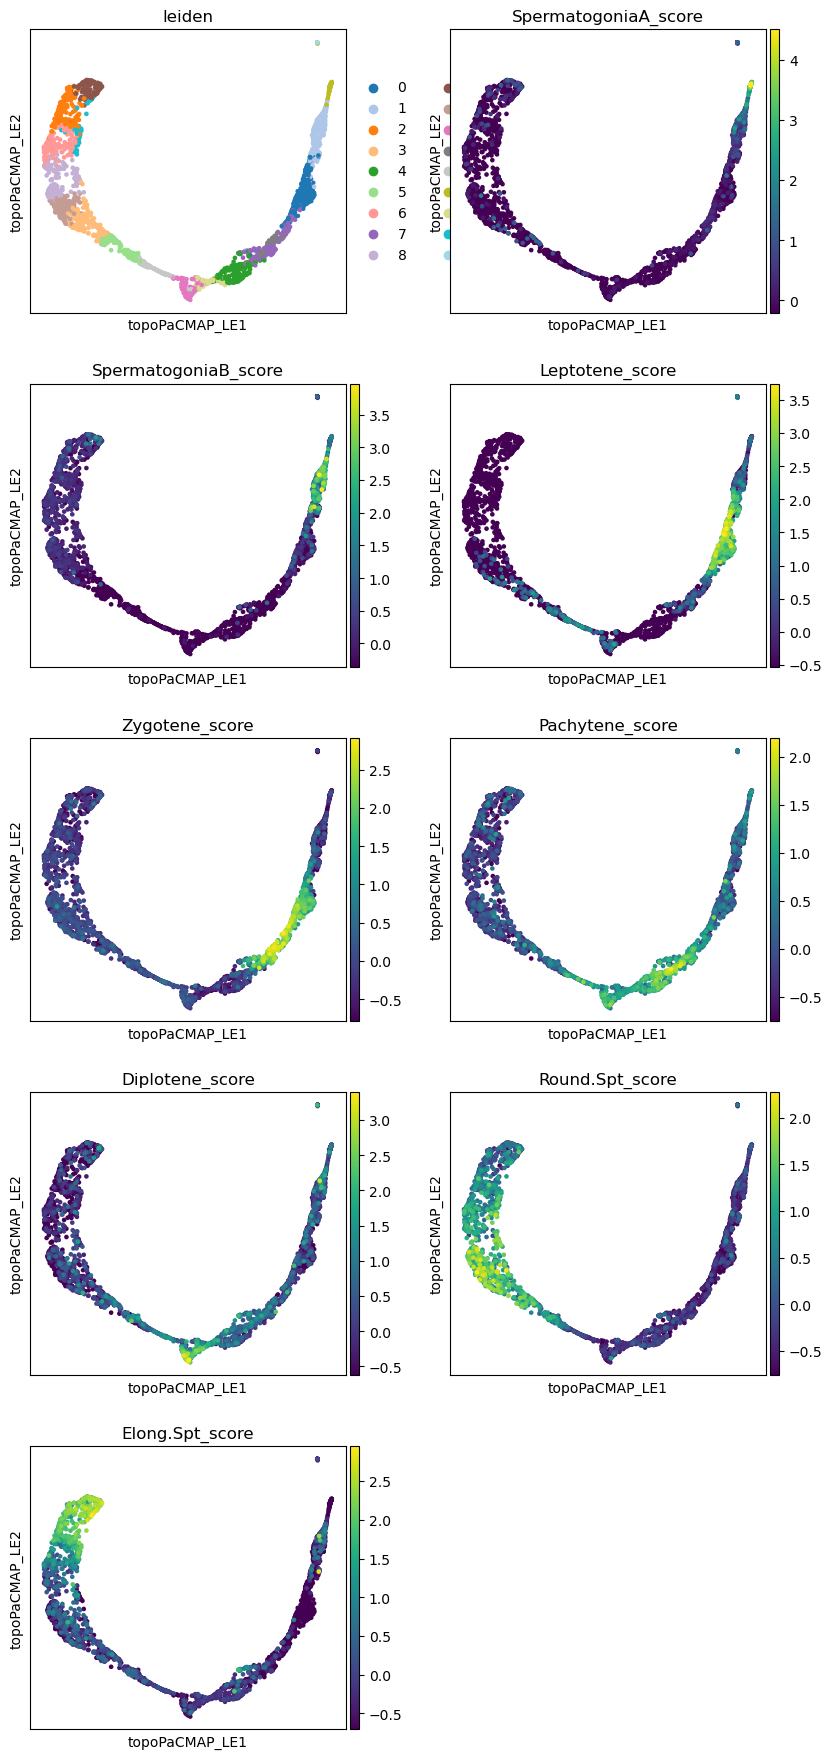

In [87]:
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_LE",
    color=["leiden", "SpermatogoniaA_score", "SpermatogoniaB_score", 'Leptotene_score', 'Zygotene_score', 'Pachytene_score', 'Diplotene_score', 'Round.Spt_score', 'Elong.Spt_score'],
    palette="tab20",
    ncols=2,
    legend_fontsize=10,
)

In [88]:
adata.obs["clusters_single"] = clustersByScores(
    adata, markers_scores, leidenClusters=adata.obs["leiden"]
)

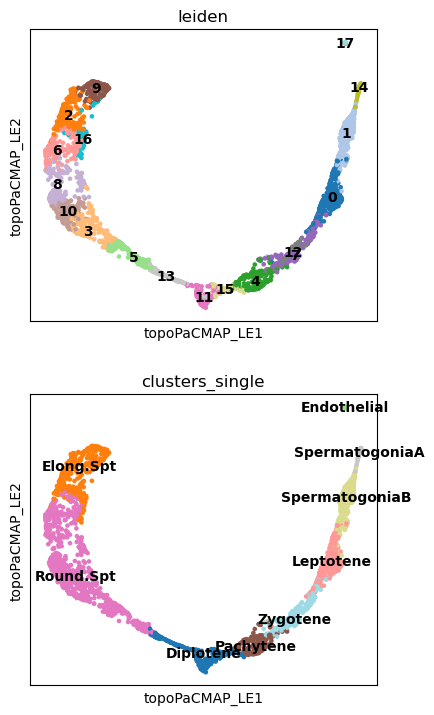

In [89]:
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_LE",
    color=["leiden", "clusters_single"],
    legend_loc="on data",
    palette="tab20",
    ncols=1,
    legend_fontsize=10,
)

In [90]:
adata.write(f'./write/adata.norm.topo.clst.h5ad')